In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
mod = "/root/sunxh/WaveCrossMamba/dataset/test.ivt.m5c.tsv"
unmod = "/root/sunxh/WaveCrossMamba/dataset/test.ivt.unmod.c.tsv"
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}
def load_predict_data(file,data_length=50):
    X=[]
    count = 0
    with open(file) as f:
        for line in f:
            line=line.rstrip()
            items=line.split("\t")
            signals="|".join(items[9:14]).split("|")
            signal=np.array([float(signal) for signal in signals])
            kmer = items[3]
            if kmer != "AACAG":
                continue
            kmer=np.array([kmer_encode_dic[base] for base in kmer])
            x = signal
            count += 1
            if count > data_length:
                break
            X.append(x)
    return np.array(X)

x = load_predict_data(mod,data_length=50)
y = load_predict_data(unmod,data_length=50)

In [2]:
xx = x
yy = y
print(x.shape)

(50, 500)


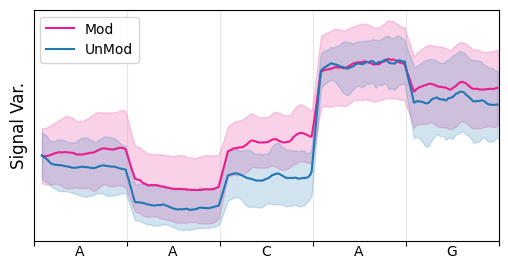

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
mod_signals = xx
nonmod_signals = yy
time_points = np.arange(500)
window_size = 10 
mod_mean = np.mean(mod_signals, axis=0) 
nonmod_mean = np.mean(nonmod_signals, axis=0) 
mod_std = np.std(mod_signals, axis=0) 
nonmod_std = np.std(nonmod_signals, axis=0)  
mod_mean_rolling = np.convolve(mod_mean, np.ones(window_size)/window_size, mode='valid')
nonmod_mean_rolling = np.convolve(nonmod_mean, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(6, 3))
mod_color = (232/255, 30/255, 141/255)
unmod_color = (31/255, 119/255, 180/255)
plt.plot(time_points[window_size-1:], mod_mean_rolling, color=mod_color, label='Mod')
plt.plot(time_points[window_size-1:], nonmod_mean_rolling, color=unmod_color, label='UnMod')

plt.fill_between(time_points[window_size-1:], 
                 mod_mean_rolling - np.convolve(mod_std, np.ones(window_size)/window_size, mode='valid'), 
                 mod_mean_rolling + np.convolve(mod_std, np.ones(window_size)/window_size, mode='valid'), 
                 color=mod_color, alpha=0.2)
plt.fill_between(time_points[window_size-1:], 
                 nonmod_mean_rolling - np.convolve(nonmod_std, np.ones(window_size)/window_size, mode='valid'), 
                 nonmod_mean_rolling + np.convolve(nonmod_std, np.ones(window_size)/window_size, mode='valid'), 
                 color=unmod_color, alpha=0.2)
custom_labels = ["A", "A", "C", "A", "G"]

tick_positions = np.arange(0, 501, 100)

label_positions = (tick_positions[:-1] + tick_positions[1:]) / 2

plt.xlabel("", fontsize=12)
plt.ylabel("Signal Var.", fontsize=12)
plt.title("", fontsize=14)
plt.legend()
plt.yticks([])
plt.xlim(0, time_points[-1])
plt.xticks(tick_positions,[""]*len(tick_positions))
for pos, label in zip(label_positions, custom_labels):
    plt.text(pos, -0.75, label, ha='center', va='top', fontsize=10)

plt.grid(alpha=0.3)
plt.savefig("/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/f22_time_signal.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()